In [ ]:
import numpy as np
from numpy.linalg import inv, det, norm, svd, pinv, matrix_rank
from scipy.linalg import null_space, orth
import matplotlib.pyplot as plt
from sklearn import linear_model
import cvxpy as cvx
from time import time

# Метод наименьших квадратов (Least-squares)

**Данно**: матрица $A$, вектор столбец $y$, а так же есть переменная (вектор столбец) $x$.

**Задача:** минимизируйте невязку $Ax-y$, по $x$

$
\underset{x}{\text{minimize}} \space
||Ax-y||
$

Вариант 1:

$
A=
\begin{bmatrix}
0 &  3 &  0 &  0 \\
0 &  0 & -5 &  0 \\
2 &  0 &  0 &  0 \\
0 &  0 &  0 &  7
\end{bmatrix}
\space
y =
\begin{bmatrix}
3 \\
-5 \\
2 \\
7
\end{bmatrix}
$

Вариант 2:

$
A=
\begin{bmatrix}
3 & -2 \\
6 &  1
\end{bmatrix}
\space
y =
\begin{bmatrix}
1 \\
7
\end{bmatrix}
$

Сколько решений существует?

В чем заключается отличие левой обратной матрицы от правой обратной матрицы?

Когда обратные матрицы существуют?

# Null space (Ядро или Kernel)

Что такое Null Space?

Что дает умножение матрицы $A$ на её Null Space $N$ ($AN$)?

**Данно**: матрица $A$ и переменная $x$.

**Задача:** Решите $Ax = 0$

Вариант 1:

$
A=
\begin{bmatrix}
1 &  2 &  3 \\
2 &  5 &  4
\end{bmatrix}
$

Вариант 2:

$
A=
\begin{bmatrix}
5 &  6 &  3 \\
7 &  8 &  4 \\
5 &  6 &  3
\end{bmatrix}
$

Сколько решений существует?

Сколько векторов Null Space вы нашли?

Какой ранг у матриц?

# Псевдообратная матрица (Pinv)

Поздравляю, теперь вы будете решать задачи на компьютере


**Данно**: матрица $A$, вектор $y$, и переменная $x$.

**Задача:** минимизируйте невязку $Ax-y$, по $x$

$
\underset{x}{\text{minimize}} \space
||Ax-y||
$

$
A=
\begin{bmatrix}
3 &  1 &  1 \\
4 &  5 &  3 \\
8 &  6 &  9 \\
7 &  9 &  6 \\
5 &  3 &  2
\end{bmatrix}
$

Какой ранг у матрицы?

Сколько решений существует?

Как выглядит Null space?

Решите задачу используя несколько способов (Левая и правая обратная матрица, псевдоборатная матрица)

Сравните полученыые решения. Какой метод стоит преминить, а какой нет? Почему?

Оцените невязку

In [ ]:
A = np.array([[3, 1, 1],
              [4, 5, 3],
              [8, 6, 9],
              [7, 9, 6],
              [5, 3, 2]])

y = np.array([[1, 1, 1, 1, 1]]).T

x_pinv = pinv(A) @ y
y_pinv = A @ x_pinv
e_pinv = norm(y - y_pinv)

x_pinv, y_pinv, e_pinv

(array([[ 0.31375232],
        [-0.01348842],
        [-0.15922197]]),
 array([[0.76854657],
        [0.70990128],
        [0.99609031],
        [1.11953866],
        [1.20985241]]),
 np.float64(0.44279878649459165))

In [ ]:
x_left = inv(A.T @ A) @ A.T @ y
y_left = A @ x_left
e_left = norm(y - y_left)

x_left, y_left, e_left

(array([[ 0.31375232],
        [-0.01348842],
        [-0.15922197]]),
 array([[0.76854657],
        [0.70990128],
        [0.99609031],
        [1.11953866],
        [1.20985241]]),
 np.float64(0.44279878649459165))

In [ ]:
x_right = A.T @ inv(A @ A.T) @ y
y_right = A @ x_right
e_right = norm(y - y_right)

x_right, y_right, e_right

(array([[0.48828125],
        [0.13671875],
        [0.08203125]]),
 array([[1.68359375],
        [2.8828125 ],
        [5.46484375],
        [5.140625  ],
        [3.015625  ]]),
 np.float64(6.719719679299083))

In [ ]:
null_space(A)

array([], shape=(3, 0), dtype=float64)

А что произойдет, если транспонировать матрицу $A$ из прошлого задания?

**Данно**: матрица $A$, вектор $y$, и переменная $x$.

**Задача:** минимизируйте невязку $Ax-y$, по $x$

$
\underset{x}{\text{minimize}} \space
||Ax-y||
$

$
A=
\begin{bmatrix}
3 &  4 &  8 & 7 & 5 \\
1 &  5 &  6 & 9 & 3 \\
1 &  3 &  9 & 6 & 2
\end{bmatrix}
$

Какой ранг у матрицы?

Сколько решений существует?

Как выглядит Null space?

Решите задачу используя несколько способов (Левая и правая обратная матрица, псевдоборатная матрица)

Сравните полученыые решения. Какой метод стоит преминить, а какой нет? Почему?

Оцените невязку

In [ ]:
A = np.array([[3, 1, 1],
              [4, 5, 3],
              [8, 6, 9],
              [7, 9, 6],
              [5, 3, 2]]).T

y = np.array([[1, 1, 1]]).T

x_pinv = pinv(A) @ y
y_pinv = A @ x_pinv
e_pinv = norm(y - y_pinv)

x_pinv, y_pinv, e_pinv

(array([[-0.00465904],
        [ 0.02456586],
        [ 0.06861499],
        [ 0.05209657],
        [ 0.00042355]]),
 array([[1.],
        [1.],
        [1.]]),
 np.float64(5.20740757162067e-16))

In [ ]:
x_left = inv(A.T @ A) @ A.T @ y
y_left = A @ x_left
e_left = norm(y - y_left)

x_left, y_left, e_left

(array([[ 2.        ],
        [-0.15625   ],
        [ 0.0625    ],
        [ 0.06835938],
        [-0.3125    ]]),
 array([[4.79101562],
        [1.27148438],
        [1.87890625]]),
 np.float64(3.901022869857641))

In [ ]:
x_right = A.T @ inv(A @ A.T) @ y
y_right = A @ x_right
e_right = norm(y - y_right)

x_right, y_right, e_right

(array([[-0.00465904],
        [ 0.02456586],
        [ 0.06861499],
        [ 0.05209657],
        [ 0.00042355]]),
 array([[1.],
        [1.],
        [1.]]),
 np.float64(1.4217791915866692e-15))

In [ ]:
null_space(A)

array([[-0.05994538, -0.78818753],
       [-0.86461433,  0.05798678],
       [-0.0536446 ,  0.05641162],
       [ 0.47175301, -0.176877  ],
       [ 0.15303582,  0.5838923 ]])

# Сингулярное разложение (SVD)
В прошлых задачах мы часто вызывали функции pinv, null_space и matrix_rank.
Но как вы знаете все эти функции используют сингулярное разложение (SVD).
Давайте посмотрим в документацию и исходный код библиотек.

1.   pinv
     * [Документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)
     * [Код](https://github.com/numpy/numpy/blob/v2.4.0/numpy/linalg/_linalg.py#L2153-L2265)
2.   null_space
     * [Документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.null_space.html#scipy.linalg.null_space)
     * [Код](https://github.com/scipy/scipy/blob/v1.17.0/scipy/linalg/_decomp_svd.py#L361-L437)
3.   matrix_rank
     * [Документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html)
     * [Код](https://github.com/numpy/numpy/blob/v2.4.0/numpy/linalg/_linalg.py#L2035-L2144)


А теперь посмотрим насколько мы были не эффективны.

**Задача:** Оцените за какое время МНК работает с функциями pinv, null_space и matrix_rank, и с одним SVD.  Постарайтесь создать несколько матриц $A$ и векторов $y$, оцените время для каждой. Расчитайте невязку для различных положений в Null Space

##  Ваш код с функциями pinv, null_space и matrix_rank

In [ ]:
# Напишите свой код

In [ ]:
n = np.array([[1, 1]]).T
A, y, n

(array([[3, 4, 8, 7, 5],
        [1, 5, 6, 9, 3],
        [1, 3, 9, 6, 2]]),
 array([[1],
        [1],
        [1]]),
 array([[1],
        [1]]))

In [ ]:
start = time()
r = matrix_rank(A)
y_hat = A@pinv(A)@y + A@null_space(A)@n
end = time()
end - start

0.0008180141448974609

## Ваш код с сингулярным разложением (SVD)

In [ ]:
U, S, Vh = svd(A)
U, S, Vh

(array([[-0.60901288,  0.14851462, -0.77913203],
        [-0.58186004, -0.75122029,  0.31161992],
        [-0.53901967,  0.64312634,  0.54391755]]),
 array([20.69738425,  3.35393378,  2.52376971]),
 array([[-0.14242951, -0.33639085, -0.63845944, -0.61524434, -0.28354713],
        [ 0.10061317, -0.36752781,  0.73613031, -0.55535449, -0.06703623],
        [-0.5871608 ,  0.02905341,  0.21076455,  0.24335039, -0.74213004],
        [-0.05994538, -0.86461433, -0.0536446 ,  0.47175301,  0.15303582],
        [-0.78818753,  0.05798678,  0.05641162, -0.176877  ,  0.5838923 ]]))

In [ ]:
start = time()
U, S, Vh = svd(A)
r = len(S)
S_inv = np.zeros(A.shape).T
S_inv[:r,:r] = np.diag(1/S)
A_inv = Vh.T @ S_inv @ U.T

A_null = Vh[r:,:].T
y_hat = A@A_inv@y + A@A_null@n
end = time()
print(end - start)
norm(y_hat- y)

0.0007963180541992188


np.float64(1.926164957854745e-15)

Также хочется вспомнить о [backslash (\\, mldivide)](https://www.mathworks.com/help/matlab/ref/double.mldivide.html) из Matlab, эта функция эффективно решает линейные уравнения, благодаря нескольким ветвленияим. Блок-схему ветвления, вы сможете найти по [ссылке](https://www.mathworks.com/help/matlab/ref/mldivide_full.png).

В Python нет полноценной реализации backslash, но есть [solve](https://numpy.org/devdocs/reference/generated/numpy.linalg.solve.html) (для квадратных матриц) и [lstsq](https://numpy.org/devdocs/reference/generated/numpy.linalg.lstsq.html) (для остальных случаев)

# Линейная регрессия (Опять)

МНК (и pinv в частности) позволяет найти параметры линейной регрессии.

**Задача:** Реализуйте линейную регресию используя псевдообратную матрицу, сравните результаты с линейной регресиией из sklearn и с истиными значениями.

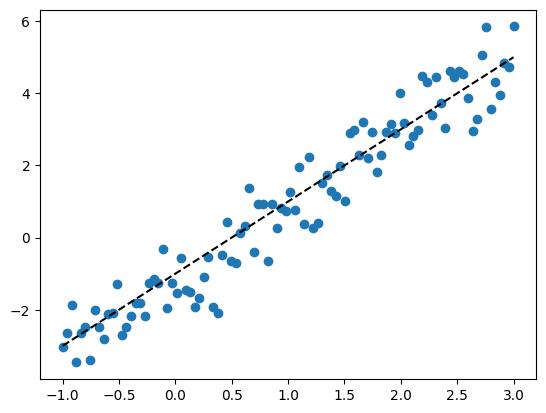

In [ ]:
x = np.linspace(-1, 3, 100)
a, b = 2, -1
y_noise = a*x+b + np.random.normal(0, 1, 100)*0.6
plt.scatter(x, y_noise)
plt.plot(x, a*x+b, "--k")

In [ ]:
# Напишите свой код
# Подсказка: дополните ваши вектора x и y векторами из единиц

# Параметры окружности (Снова)

Ниже представлен пример использования CVXPY для нахождения параметров окружности. Как вы можете заметить, решение и постанока задачи оптимизации в CVXPY крайне лаконична и проста.

**Задача:**
Оригинальная задача в CVXPY ставиться по уравнению:

$
r^2  = \frac{1}{m} \sum_{i=1}^m  \left \| u_i -x_c \right \|_2^2
$

Сформулируйте задачу как МНК и решите её

$
\underset{x}{\text{minimize}} \space
||Ax_c-u||
$


[2.99765036 3.99581198]


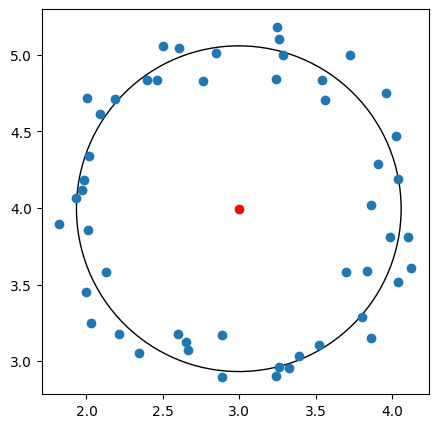

In [ ]:
npoints = 50
r = 1
c1 = (3, 4)
plt.figure(figsize=(5,5))
t = np.linspace(0, 2*np.pi, npoints, endpoint=False)
x = c1[0] + r * np.cos(t) + np.random.uniform(-0.2,0.2,t.shape[0])
y = c1[1] + r * np.sin(t) + np.random.uniform(-0.2,0.2,t.shape[0])
plt.scatter(x, y, c='0.8')
U = np.vstack((x,y))

# Здесь начинается CVXPY
cx = cvx.Variable()
cy = cvx.Variable()
obj = cvx.Minimize(cvx.norm(cvx.vstack((U[0,:] - cx, U[1,:] - cy))))
prob = cvx.Problem(obj, [])
prob.solve(verbose=False)  # verbose=True (для визуализации ответа)
xc = np.array([cx.value, cy.value])
# Здесь заканчивается. Выше включен режим подробной информации (по умолчанию verbose=False)

print(xc)
r_hat = (U.T - xc)
mean_r = np.sum(r_hat * r_hat, axis=1).mean()
r = np.sqrt(mean_r)

ax = plt.gca()
ax.clear()
circle = plt.Circle(xc, r, fill=False)
ax.add_patch(circle)
plt.scatter(U[0,:], U[1,:])
plt.scatter([xc[0]], [xc[1]], color="r")
plt.show()

In [ ]:
# Напишите свой код

# Аналитические решения


**Задача:**

Вы едите на машине по трассе и у вас возникают проблемы со связью.

 Найдите место на трассе, в котором растояние до всех ближайших вышек минимально

**Задача:**

Спутник вращается вокруг земли по эллиптической орбите
<!-- $ x^T H x$ -->

Найдите точку, в которой спутник ближе всего к остальным спутникам

**Задача:**

У вас есть модель линейной и дискретной динамики
<!-- $x_{i+1} = A x_i + B u_i$ -->

Найдите следующее состояния, которое максимально близко к желаему состоянию

**Задача:**

У вас все еще есть модель линейной и дискретной динамики
<!-- $x_{i+1} = A x_i + B u_i$ -->

Найдите следующее состояния, которое максимально близко к желаему состоянию.
Но растояние между двумя любыми последовательными состояниями должно быть ограничено
<!-- (Минимизация длинны или заданная длина шага) -->
<!-- $ \text{min} \space (x_{i+1} - x_i)^T (x_{i+1} - x_i) $ -->
<!-- $ (x_{i+1} - x_i)^T (x_{i+1} - x_i) = h $ -->